# Adult Income Dataset — Fairness-Aware Loss Function Study

**Dataset:** UCI Adult Income (Census Income) Dataset (UCI Repository, ID=2)
**Task:** Binary classification — income >50K vs ≤50K prediction
**Sensitive Attribute:** Sex (Female=0, Male=1)
**Outcome Type:** FAILS — no viable operating point for either DP or EO

This notebook is part of a five-dataset study examining whether fairness
regularization produces a viable operating region, fails, or is unnecessary,
based on two pre-training diagnostic properties: Base Rate Disparity (BRD)
and Positive Class Sparsity (PCS).

Key finding: BRD=0.199 creates a severe gradient conflict — DP disparity
actually WORSENS under regularization (0.176→0.307 at λ=2). PCS=0.037
is too sparse for EO gradient signal. This is the study's primary example
of the CONFLICT outcome regime. Adaptive framework saved 41.6% of DP
accuracy damage and 100% of EO accuracy damage vs standard λ=2.

Note: This dataset uses a validation set during training (unlike other
notebooks) due to its larger scale (~45K samples). Two separate training
functions handle DP and EO respectively.

## Section 1 — Data Loading & Initial Inspection
Fetch Adult Income dataset from UCI repository (48,842 samples, 15 columns).
Inspect feature types, target distribution (income >50K vs ≤50K),
and identify missing value encoding — dataset uses both NaN and "?"
as missing value representations, requiring two separate checks.

In [ ]:
# Installed the package for the datasets.
!pip install ucimlrepo

In [ ]:
# Important import for vieweing and playing with the data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fetching the data
from ucimlrepo import fetch_ucirepo
adult = fetch_ucirepo(id=2)

# Extracting the data
X = adult.data.features   # input features
y = adult.data.targets    # target variable

# Combining
df = pd.concat([X, y], axis=1)

# and giving first look at the data
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
# Here we are dropping unnecessary columns, for now fnlwgt and education are being dropped but later
# on, checking information gain on particular column and deciding to drop or not.

df = df.drop(columns=["fnlwgt", "education"])
df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [ ]:
# Identifying any missing values (1)
df.isna().sum()

,0
age,0
workclass,963
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [ ]:
# Identifying any missing values (1)
(df == "?").sum()

,0
age,0
workclass,1836
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


What did we **observed** from the **missing values**:
- We got differnt outputs for both the checks, this means the dataset contains two types of missing representation, "NaN" and "?".
- df.isna() only counts NaN
- df == "?" only counts string "?"
- So the true number might be an addition of both the values we dont know yet.
- We saw missing values in three columns which are "workclass", "occupation", "native-country".

Now after the **observations** what are the **options** which we can explore with **cleaning the data**.

**1.** Drop rows with the missing values: This is very common solution used in datsets, plus we have around 48 thousand rows and losing 3-4 thousand rows wont affect much.
- Benefits are will help in cleaning and there will be no artificial bias.

**2.** Replacing with Mode imputation, where we can add the most common occupation
- It will create an artificial increase and biases the model.

**3.** Dropping the entire column: It would be a dumb move especially in occupation and workclass as they are strong predictors an dropping would weaken the model.

In [ ]:
# We are starting with dropping the rows which have missing values,
# Statisticalyy they would be around 6-8% of our total data.

df.replace("?", np.nan, inplace=True)

print(df.isna().sum())

# Here we drop rows with missing values
df = df.dropna()
print("--------------------")
# Verifying.
print(df.isna().sum())
print(df.shape)

age                  0
workclass         2799
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64
--------------------
age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
(45222, 13)


**Observation:**

As we can see in total we had around 3000 missing values, after merging the "?" and "NaN" we dropped the rows respectively.

**Result:**

Now we have 0 missing values in all columns which makes dataset structurallu clean with no redundant and missing values.


---


**Step 1:** Separate Target Variable

In [ ]:
df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [ ]:
# Clean labels first
df["income"] = df["income"].str.replace(".", "", regex=False)

# Convert to binary target
df["target"] = (df["income"] == ">50K").astype(int)

# Drop original column
df.drop(columns=["income"], inplace=True)

In [ ]:
y = df["target"]
X = df.drop(columns=["target"])

In [ ]:
df["target"].value_counts()

,count
target,
0,34014
1,11208


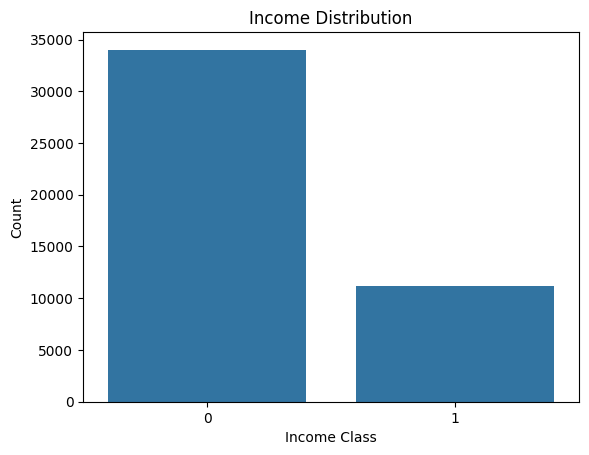

In [ ]:
import seaborn as sns

sns.countplot(x="target", data=df)
plt.title("Income Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

The dataset is moderately imbalanced, with the majority of individuals earning less than $50K annually. This imbalance may influence the classifier to favor the majority class, making evaluation metrics such as AUC important in addition to accuracy.
- 0 → ≤50K (lower income group)
- 1 → >50K (higher income group)

**Step 2:** Identifying Categorial Columns

In [ ]:
X.dtypes

,0
age,int64
workclass,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object
capital-gain,int64
capital-loss,int64


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
print(categorical_cols)

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object')


In [ ]:
# Sensitive attribute first
df["sex"] = df["sex"].str.strip().str.lower()
df["sex"] = df["sex"].map({"female": 0, "male": 1})

A = df["sex"].copy()

# Features + target
X = df.drop(columns=["target"])
y = df["target"]

# Remove sensitive attribute from X
X = X.drop(columns=["sex"])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

So we will have, Male = 1 and Female = 0.

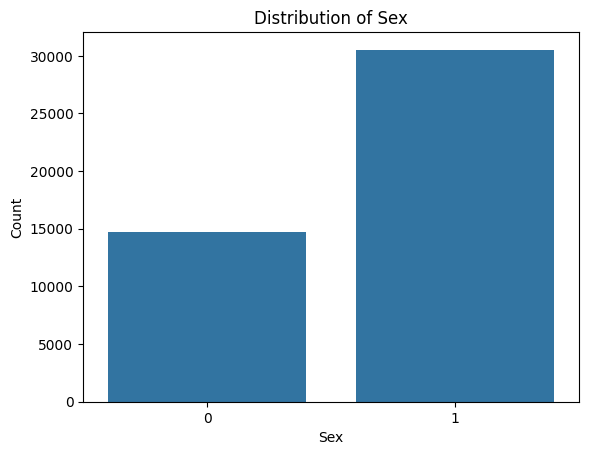

In [ ]:
sns.countplot(x="sex", data=df)
plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

Male = 67%

Female = 33%

The dataset contains a higher proportion of male individuals than female individuals. Such imbalance in sensitive attributes may contribute to disparities in model predictions across demographic groups.

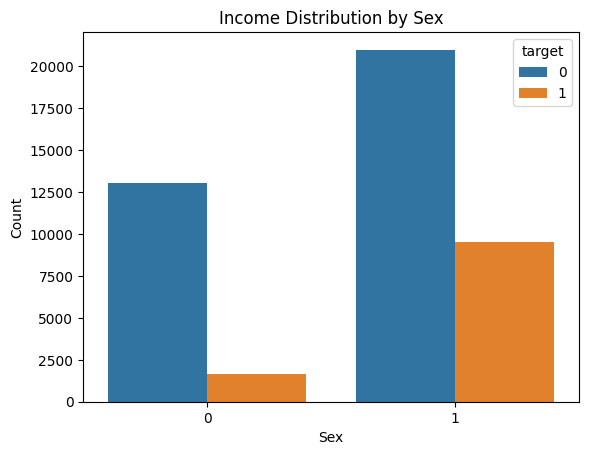

In [ ]:
sns.countplot(x="sex", hue="target", data=df)
plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

Observation: Male are much more likely to be earning more than 50K.

**Step 5:** Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp, A_train, A_temp = train_test_split(
  X, y, A,
  test_size=0.3,
  random_state=42,
  stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test, A_val, A_test = train_test_split(
  X_temp, y_temp, A_temp,
  test_size=0.5,
  random_state=42,
  stratify=y_temp
)

**Step 6:** Scaling for logistic regression

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Converting to numpy

In [ ]:
import numpy as np

X_train_scaled = X_train_scaled.astype(np.float64)
X_val_scaled = X_val_scaled.astype(np.float64)
X_test_scaled = X_test_scaled.astype(np.float64)

y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

A_train = A_train.values
A_val = A_val.values
A_test = A_test.values

In [ ]:
# Check
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

print(len(y_train), len(y_val), len(y_test))
print(len(A_train), len(A_val), len(A_test))

(31655, 79)
(6783, 79)
(6784, 79)
31655 6783 6784
31655 6783 6784


**Step 7:** Baseline Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

model = LogisticRegression(
  max_iter=1000,
  solver="lbfgs",
  random_state=42
)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

**Step 8:** Baseline Performance, ROC Curve

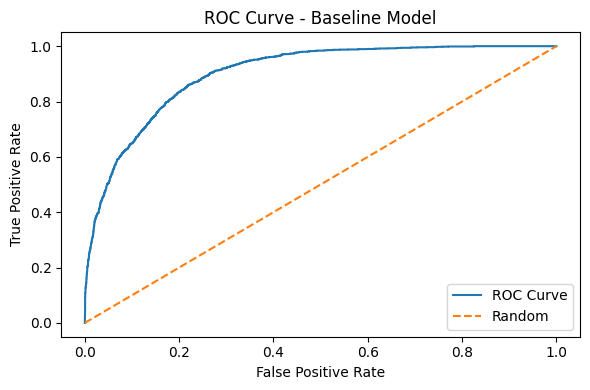

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Model")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy: 0.8454
AUC: 0.9006


The baseline logistic regression model achieves strong predictive performance, with an accuracy of approximately 85% and an AUC close to 0.90. These results indicate that the model effectively distinguishes between individuals earning above and below $50K.

**Step 9:** Demographic Parity Difference (Are both groupt selected at the same rate?)

P(pred=1 | male) − P(pred=1 | female)




In [ ]:
def demographic_parity_difference(y_pred, A):
  # Group masks
  group0 = y_pred[A == 0]  # Female
  group1 = y_pred[A == 1]  # Male

  # Mean predictions
  dp0 = group0.mean()
  dp1 = group1.mean()

  # Difference
  dp_diff = abs(dp1 - dp0)

  return dp_diff, dp0, dp1

**Step 10:** Equal Opportunity Difference
TPR_male − TPR_female

In [ ]:
def equal_opportunity_difference(y_true, y_pred, A):
  # Masks
  mask_male = (A == 1)
  mask_female = (A == 0)

  # True positive subsets
  male_pos = (y_true == 1) & mask_male
  female_pos = (y_true == 1) & mask_female

  # Avoid division by zero
  tpr_male = np.sum(y_pred[male_pos] == 1) / max(np.sum(male_pos), 1)
  tpr_female = np.sum(y_pred[female_pos] == 1) / max(np.sum(female_pos), 1)

  # Difference
  eo_diff = abs(tpr_male - tpr_female)

  return eo_diff, tpr_male, tpr_female

In [ ]:
# Demographic Parity
dp_diff, dp_female, dp_male = demographic_parity_difference(y_pred, A_test)

print(f"DP Female: {dp_female:.4f}")
print(f"DP Male: {dp_male:.4f}")
print(f"Demographic Parity Difference: {dp_diff:.4f}")

print()

# Equal Opportunity
eo_diff, tpr_male, tpr_female = equal_opportunity_difference(y_test, y_pred, A_test)

print(f"TPR Male: {tpr_male:.4f}")
print(f"TPR Female: {tpr_female:.4f}")
print(f"Equal Opportunity Difference: {eo_diff:.4f}")

DP Female: 0.0792
DP Male: 0.2570
Demographic Parity Difference: 0.1778

TPR Male: 0.6061
TPR Female: 0.5141
Equal Opportunity Difference: 0.0921


- 26.33% of male individuals are predicted to earn >50K by the model. (includes both correct and incorrect prediction)
- 7.51% of female individuals are predicted to earn >50K.

Conclusion: Correctness does not matter here,

"The model predicts high income 18.8 percentage points more often for males than females."

The model's ability to correctly identify high-income individuals differs by 15 percentage points across groups.
- Among males who actually earn >50K, the model correctly identifies 61.25% of them.
- Among females who actually earn >50K, the model correctly identifies 45.89% of them.

The model is 15.36 percentage points better at recognizing high-income males than high-income females.

**Stage 2 Conclusion:**

The exploratory analysis of the Adult Income dataset reveals underlying disparities in income distribution across demographic groups, particularly between male and female individuals. The baseline logistic regression model achieves strong predictive performance, with high accuracy and AUC values. However, fairness evaluation indicates measurable disparities across sensitive groups. The demographic parity difference suggests that the probability of receiving a positive prediction differs between males and females, while the equal opportunity difference indicates variation in true positive rates across groups. These results highlight the presence of fairness concerns in the baseline model and motivate the need for fairness-aware optimization methods explored in the next stage of the project.
- Your model is accurate BUT There is clear demographic disparity.

---
# Stage 3 and 4 Starts
---

In [ ]:
# Sigmoid
def sigmoid(z):
  z = np.clip(z, -500, 500)  # numerical stability
  return 1 / (1 + np.exp(-z))

In [ ]:
# Initializing Parameters
def initialize_params(n_features):
  w = np.zeros(n_features)
  b = 0
  return w, b

In [ ]:
# Predict Probabilities
def predict_proba(X, w, b):
  return sigmoid(np.dot(X, w) + b)

In [ ]:
# Log loss
def compute_log_loss(y, y_hat):
  eps = 1e-15
  y_hat = np.clip(y_hat, eps, 1 - eps)
  return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

In [ ]:
# Gradients
def compute_gradients(X, y, y_hat):
  m = len(y)

  dw = (1/m) * np.dot(X.T, (y_hat - y))
  db = (1/m) * np.sum(y_hat - y)

  return dw, db

In [ ]:
def train_logistic_regression(
  X_train, y_train,
  X_val, y_val,
  lr=0.01,
  epochs=50
):
  n_samples, n_features = X_train.shape

  # Initialize parameters
  w, b = initialize_params(n_features)

  # Tracking
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
    # Forward Pass
    y_hat_train = predict_proba(X_train, w, b)

    # Compute Loss
    train_loss = compute_log_loss(y_train, y_hat_train)

    # Gradients
    dw, db = compute_gradients(X_train, y_train, y_hat_train)

    # Update
    w -= lr * dw
    b -= lr * db

    # Validation Loss
    y_hat_val = predict_proba(X_val, w, b)
    val_loss = compute_log_loss(y_val, y_hat_val)

    # Store
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Print
    if epoch % 10 == 0:
      print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

  print(f"Final Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

  return (w, b), train_losses, val_losses

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

results_lr = {}
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for lr in learning_rates:
  print(f"\n=== Learning Rate: {lr} ===")

  params, train_losses, val_losses = train_logistic_regression(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    lr=lr,
    epochs=50
  )

  w, b = params

  # Evaluation
  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)

  acc = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_prob)

  print(f"Accuracy: {acc:.4f}")
  print(f"AUC: {auc:.4f}")

  key = f"lr={lr}"

  results_lr[key] = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "accuracy": acc,
    "auc": auc
  }


=== Learning Rate: 0.001 ===
Epoch 0: Train Loss = 0.6931, Val Loss = 0.6929
Epoch 10: Train Loss = 0.6908, Val Loss = 0.6906
Epoch 20: Train Loss = 0.6885, Val Loss = 0.6883
Epoch 30: Train Loss = 0.6862, Val Loss = 0.6860
Epoch 40: Train Loss = 0.6840, Val Loss = 0.6837
Final Epoch 49: Train Loss = 0.6819, Val Loss = 0.6817
Accuracy: 0.7731
AUC: 0.8769

=== Learning Rate: 0.005 ===
Epoch 0: Train Loss = 0.6931, Val Loss = 0.6920
Epoch 10: Train Loss = 0.6817, Val Loss = 0.6806
Epoch 20: Train Loss = 0.6709, Val Loss = 0.6698
Epoch 30: Train Loss = 0.6607, Val Loss = 0.6597
Epoch 40: Train Loss = 0.6511, Val Loss = 0.6501
Final Epoch 49: Train Loss = 0.6429, Val Loss = 0.6419
Accuracy: 0.7793
AUC: 0.8778

=== Learning Rate: 0.01 ===
Epoch 0: Train Loss = 0.6931, Val Loss = 0.6908
Epoch 10: Train Loss = 0.6709, Val Loss = 0.6687
Epoch 20: Train Loss = 0.6510, Val Loss = 0.6491
Epoch 30: Train Loss = 0.6333, Val Loss = 0.6315
Epoch 40: Train Loss = 0.6173, Val Loss = 0.6157
Final Epoch

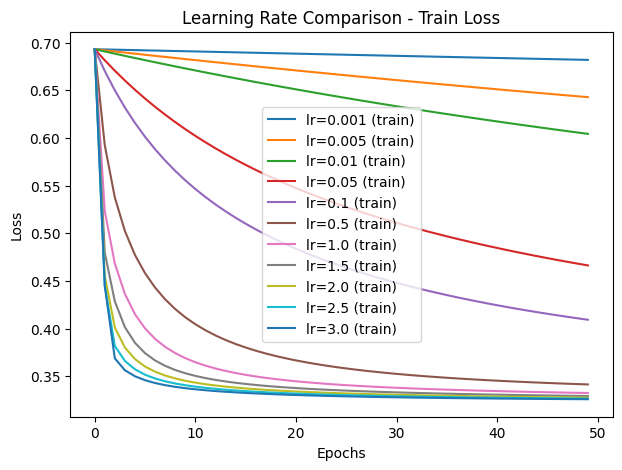

In [ ]:
plt.figure(figsize=(7,5))

for key, res in results_lr.items():
  plt.plot(res["train_loss"], label=f"{key} (train)")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison - Train Loss")
plt.legend()
plt.show()

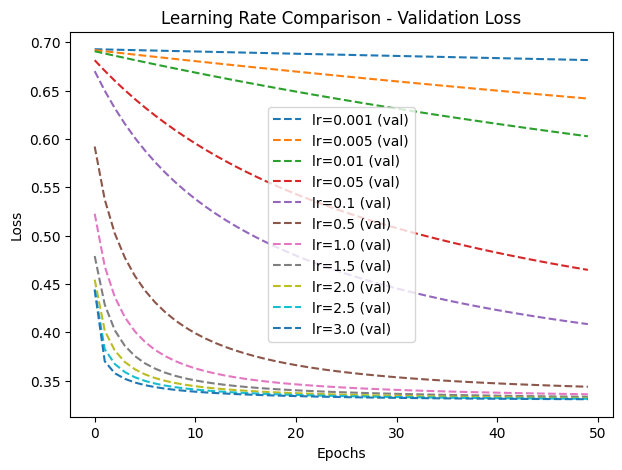

In [ ]:
plt.figure(figsize=(7,5))

for key, res in results_lr.items():
  plt.plot(res["val_loss"], linestyle="--", label=f"{key} (val)")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison - Validation Loss")
plt.legend()
plt.show()

In [ ]:
results_lr = {}
learning_rates = [5.3, 6.0]

for lr in learning_rates:
  print(f"\n=== Learning Rate: {lr} ===")

  params, train_losses, val_losses = train_logistic_regression(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    lr=lr,
    epochs=50
  )

  w, b = params

  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)

  acc = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_prob)

  print(f"Accuracy: {acc:.4f}")
  print(f"AUC: {auc:.4f}")

  results_lr[f"lr={lr}"] = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "accuracy": acc,
    "auc": auc
  }


=== Learning Rate: 5.3 ===
Epoch 0: Train Loss = 0.6931, Val Loss = 0.5134
Epoch 10: Train Loss = 0.3311, Val Loss = 0.3345
Epoch 20: Train Loss = 0.3268, Val Loss = 0.3314
Epoch 30: Train Loss = 0.3255, Val Loss = 0.3306
Epoch 40: Train Loss = 0.3249, Val Loss = 0.3303
Final Epoch 49: Train Loss = 0.3246, Val Loss = 0.3302
Accuracy: 0.8443
AUC: 0.9006

=== Learning Rate: 6.0 ===
Epoch 0: Train Loss = 0.6931, Val Loss = 0.5463
Epoch 10: Train Loss = 0.3450, Val Loss = 0.3489
Epoch 20: Train Loss = 0.3383, Val Loss = 0.3429
Epoch 30: Train Loss = 0.3344, Val Loss = 0.3394
Epoch 40: Train Loss = 0.3320, Val Loss = 0.3372
Final Epoch 49: Train Loss = 0.3306, Val Loss = 0.3368
Accuracy: 0.8417
AUC: 0.9003


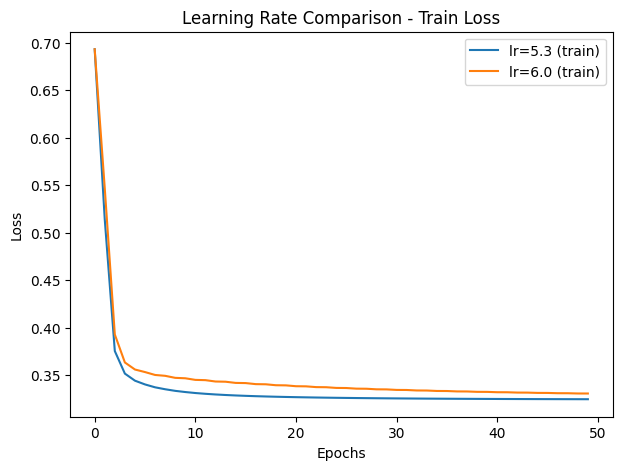

In [ ]:
plt.figure(figsize=(7,5))

for key, res in results_lr.items():
  plt.plot(res["train_loss"], label=f"{key} (train)")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison - Train Loss")
plt.legend()
plt.show()

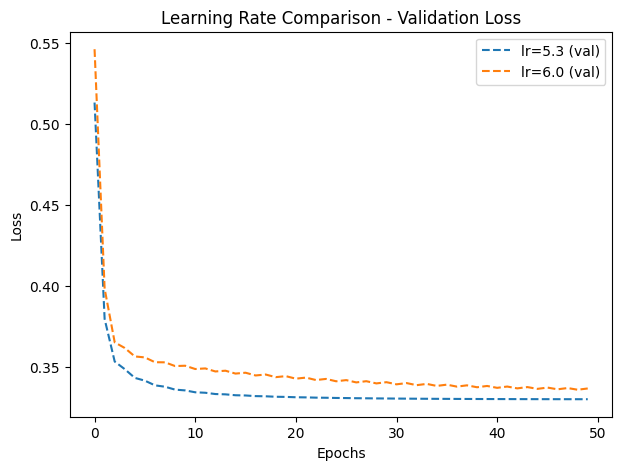

In [ ]:
plt.figure(figsize=(7,5))

for key, res in results_lr.items():
  plt.plot(res["val_loss"], linestyle="--", label=f"{key} (val)")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison - Validation Loss")
plt.legend()
plt.show()

What we noticed was LR=5.3 gave the best result and was increasing after 5.3 it started to be unstable and overshooting.



---

Moving onto the demographic parity so we are extendint the model with fairness.

$L_{pred}  →  L_{total} = L_{pred} + λ * R_{DP}$

In [ ]:
def compute_dp_penalty(y_hat, A):
  G0 = (A == 0)
  G1 = (A == 1)

  if np.sum(G0) == 0 or np.sum(G1) == 0:
    return 0

  mean_G0 = np.mean(y_hat[G0])
  mean_G1 = np.mean(y_hat[G1])

  return (mean_G0 - mean_G1) ** 2

In [ ]:
def compute_dp_gradients(X, y_hat, A):
  G0 = (A == 0)
  G1 = (A == 1)

  n0 = np.sum(G0)
  n1 = np.sum(G1)

  if n0 == 0 or n1 == 0:
    return np.zeros(X.shape[1]), 0

  mean_G0 = np.mean(y_hat[G0])
  mean_G1 = np.mean(y_hat[G1])

  diff = mean_G0 - mean_G1

  dw = np.zeros(X.shape[1])

  for i in range(len(y_hat)):
    if A[i] == 0:
      dw += diff * X[i] / n0
    else:
      dw -= diff * X[i] / n1

  dw /= len(y_hat)
  db = diff

  return dw, db

In [ ]:
def train_fair_logistic_regression(
  X_train, y_train, A_train,
  X_val, y_val, A_val,
  lr=1.0,
  lambda_val=0,
  epochs=50
):
  n_samples, n_features = X_train.shape

  w, b = initialize_params(n_features)

  train_losses = []
  val_losses = []
  fairness_vals = []

  for epoch in range(epochs):

    # Forward
    y_hat_train = predict_proba(X_train, w, b)

    # Prediction loss
    pred_loss = compute_log_loss(y_train, y_hat_train)

    # DP penalty
    dp_penalty = compute_dp_penalty(y_hat_train, A_train)

    # Total loss
    total_loss = pred_loss + lambda_val * dp_penalty

    # Gradients (prediction)
    dw_pred, db_pred = compute_gradients(X_train, y_train, y_hat_train)

    # Gradients (DP)
    dw_dp, db_dp = compute_dp_gradients(X_train, y_hat_train, A_train)

    # Combine gradients
    dw = dw_pred + lambda_val * dw_dp
    db = db_pred + lambda_val * db_dp

    # Update
    w -= lr * dw
    b -= lr * db

    # Validation
    y_hat_val = predict_proba(X_val, w, b)
    val_loss = compute_log_loss(y_val, y_hat_val)

    # Store
    train_losses.append(total_loss)
    val_losses.append(val_loss)
    fairness_vals.append(dp_penalty)

    if epoch % 10 == 0:
      print(f"Epoch {epoch}: Loss={total_loss:.4f}, Fairness={dp_penalty:.4f}")

  print(f"Final Epoch {epoch}: Loss={total_loss:.4f}, Fairness={dp_penalty:.4f}")

  return (w, b), train_losses, val_losses, fairness_vals

In [ ]:
lambda_values = [0, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
results_dp = {}

for lam in lambda_values:
    print(f"\n=== DP Training with lambda = {lam} ===")

    params, train_losses, val_losses, fairness_vals = train_fair_logistic_regression(
        X_train_scaled, y_train, A_train,
        X_val_scaled, y_val, A_val,
        lr=1.0,
        lambda_val=lam,
        epochs=50
    )

    w, b = params

    # Predictions
    y_prob = predict_proba(X_test_scaled, w, b)
    y_pred = (y_prob >= 0.5).astype(int)

    # Accuracy and AUC
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # DP difference
    dp_male   = np.mean(y_pred[A_test == 1])
    dp_female = np.mean(y_pred[A_test == 0])
    dp_diff   = abs(dp_male - dp_female)

    # EO difference
    male_pos   = (y_test == 1) & (A_test == 1)
    female_pos = (y_test == 1) & (A_test == 0)
    tpr_male   = np.sum(y_pred[male_pos] == 1) / np.sum(male_pos)
    tpr_female = np.sum(y_pred[female_pos] == 1) / np.sum(female_pos)
    eo_diff    = abs(tpr_male - tpr_female)

    print(f"Accuracy: {acc:.4f}, AUC: {auc:.4f}, DP: {dp_diff:.4f}, EO: {eo_diff:.4f}")

    results_dp[f"λ={lam}"] = {
        "train_loss":  train_losses,
        "val_loss":    val_losses,
        "fairness":    fairness_vals,
        "accuracy":    acc,
        "auc":         auc,
        "dp_diff":     dp_diff,
        "eo_diff":     eo_diff,
        "lambda":      lam
    }


=== DP Training with lambda = 0 ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3646, Fairness=0.0248
Epoch 20: Loss=0.3446, Fairness=0.0284
Epoch 30: Loss=0.3378, Fairness=0.0300
Epoch 40: Loss=0.3343, Fairness=0.0309
Final Epoch 49: Loss=0.3324, Fairness=0.0313
Accuracy: 0.8386, AUC: 0.8974, DP: 0.1763, EO: 0.0931

=== DP Training with lambda = 0.01 ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3653, Fairness=0.0248
Epoch 20: Loss=0.3452, Fairness=0.0284
Epoch 30: Loss=0.3384, Fairness=0.0301
Epoch 40: Loss=0.3348, Fairness=0.0309
Final Epoch 49: Loss=0.3328, Fairness=0.0314
Accuracy: 0.8389, AUC: 0.8975, DP: 0.1774, EO: 0.0966

=== DP Training with lambda = 0.05 ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3679, Fairness=0.0249
Epoch 20: Loss=0.3478, Fairness=0.0285
Epoch 30: Loss=0.3408, Fairness=0.0301
Epoch 40: Loss=0.3371, Fairness=0.0309
Final Epoch 49: Loss=0.3350, Fairness=0.0314
Accuracy: 0.8376, AUC: 0.8978, DP: 0.1804, EO: 0.0909

===

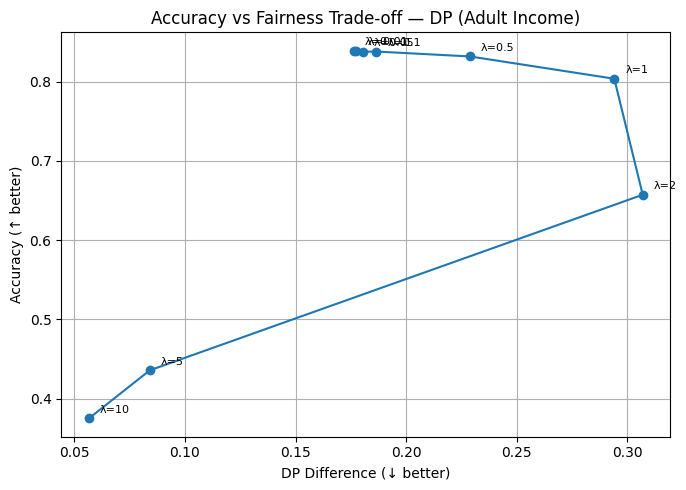

In [ ]:
# Plot 3 — Accuracy vs DP trade-off
lambdas, accs, dps = [], [], []
for key, res in results_dp.items():
  lambdas.append(res["lambda"])
  accs.append(res["accuracy"])
  dps.append(res["dp_diff"])

plt.figure(figsize=(7,5))
plt.plot(dps, accs, marker='o')
for i, lam in enumerate(lambdas):
  plt.annotate(f"λ={lam}", (dps[i], accs[i]),
                textcoords="offset points", xytext=(8,4), fontsize=8)
plt.xlabel("DP Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Accuracy vs Fairness Trade-off — DP (Adult Income)")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 0: Loss=0.6931, Fairness=0.0000
Final Epoch 9: Loss=0.3756, Fairness=0.0245
Epochs=  10 | Final Loss: 0.3756
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3714, Fairness=0.0250
Final Epoch 19: Loss=0.3524, Fairness=0.0284
Epochs=  20 | Final Loss: 0.3524
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3714, Fairness=0.0250
Epoch 20: Loss=0.3513, Fairness=0.0287
Epoch 30: Loss=0.3442, Fairness=0.0302
Epoch 40: Loss=0.3405, Fairness=0.0310
Final Epoch 49: Loss=0.3384, Fairness=0.0314
Epochs=  50 | Final Loss: 0.3384
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3714, Fairness=0.0250
Epoch 20: Loss=0.3513, Fairness=0.0287
Epoch 30: Loss=0.3442, Fairness=0.0302
Epoch 40: Loss=0.3405, Fairness=0.0310
Epoch 50: Loss=0.3382, Fairness=0.0314
Epoch 60: Loss=0.3366, Fairness=0.0317
Epoch 70: Loss=0.3354, Fairness=0.0319
Epoch 80: Loss=0.3346, Fairness=0.0321
Epoch 90: Loss=0.3339, Fairness=0.0322
Final Epoch 99: Loss=0.3334, Fairness=0.0322
Epochs= 100 | Final Loss

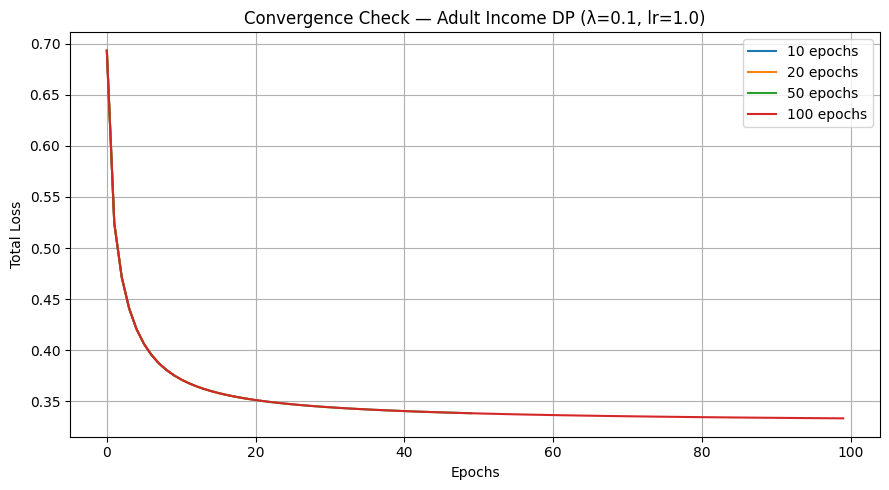

In [ ]:
# Convergence check
epoch_vals = [10, 20, 50, 100]
conv_results = {}

for ep in epoch_vals:
  params_ep, loss_ep, _, _ = train_fair_logistic_regression(
    X_train_scaled, y_train, A_train,
    X_val_scaled, y_val, A_val,
    lr=1.0,
    lambda_val=0.1,  # use a moderate lambda
    epochs=ep
  )
  conv_results[ep] = loss_ep
  print(f"Epochs={ep:4d} | Final Loss: {loss_ep[-1]:.4f}")

plt.figure(figsize=(9,5))
for ep, losses in conv_results.items():
  plt.plot(losses, label=f"{ep} epochs")
plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.title("Convergence Check — Adult Income DP (λ=0.1, lr=1.0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



---



---



---



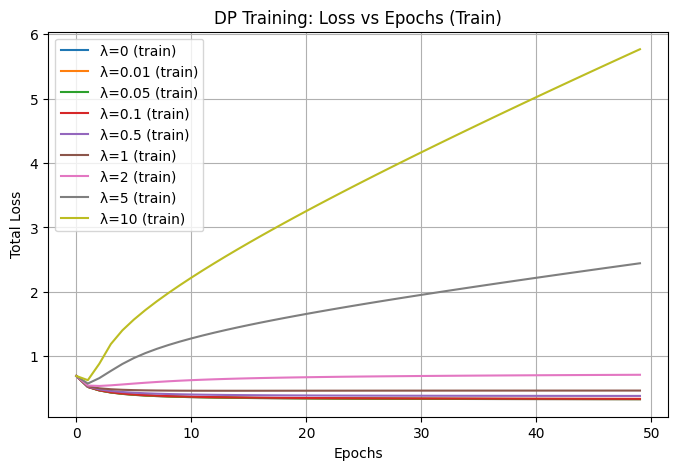

In [ ]:
plt.figure(figsize=(8,5))

for key, res in results_dp.items():
  plt.plot(res["train_loss"], label=f"{key} (train)")

plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.title("DP Training: Loss vs Epochs (Train)")
plt.legend()
plt.grid(True)
plt.show()

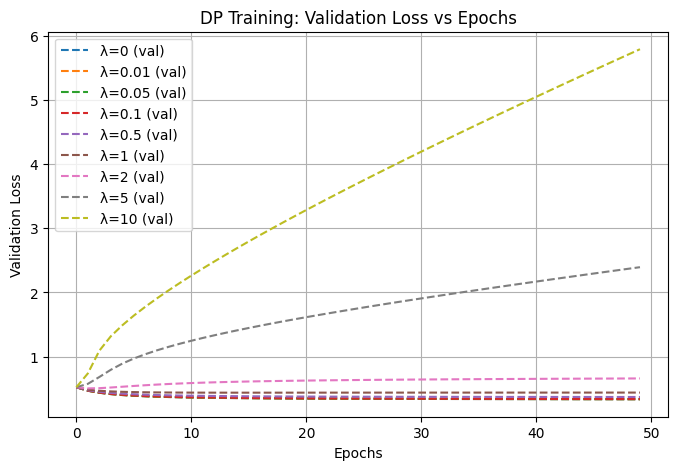

In [ ]:
plt.figure(figsize=(8,5))

for key, res in results_dp.items():
  plt.plot(res["val_loss"], linestyle="--", label=f"{key} (val)")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("DP Training: Validation Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

### Analysis of DP-Constrained Optimization

The results demonstrate how introducing a fairness constraint affects model optimization. When λ = 0, the model achieves the best predictive performance but exhibits the highest demographic disparity. As λ increases slightly (λ = 0.1), the model maintains similar accuracy and AUC while slightly reducing fairness disparity, indicating that small fairness constraints can be incorporated without harming performance.

However, as λ increases further (λ ≥ 0.5), a clear trade-off emerges. The model's accuracy and AUC begin to decline, and the training process becomes less stable. For large values of λ (λ ≥ 1), the optimization becomes highly unstable, with significant increases in loss and a drastic drop in predictive performance. This indicates that the model prioritizes fairness excessively at the expense of accuracy.

Additionally, fairness does not consistently decrease with larger λ values, suggesting that strong fairness constraints introduce instability in optimization rather than smoothly improving fairness.

Overall, these results highlight the inherent trade-off between fairness and accuracy. A moderate value of λ (around 0.1) provides the best balance, achieving slight fairness improvement without compromising predictive performance.

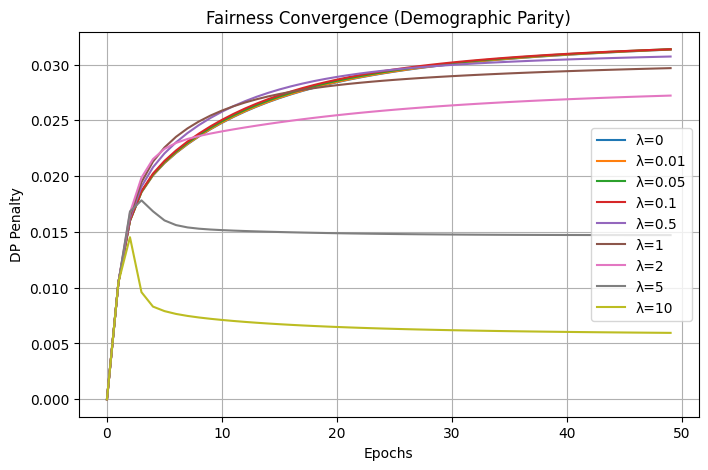

In [ ]:
plt.figure(figsize=(8,5))

for key, res in results_dp.items():
  plt.plot(res["fairness"], label=key)

plt.xlabel("Epochs")
plt.ylabel("DP Penalty")
plt.title("Fairness Convergence (Demographic Parity)")
plt.legend()
plt.grid(True)
plt.show()



---

### Equal Opportunity

In [ ]:
def compute_eo_penalty(y_hat, y, A):
  # masks for positive class
  mask_pos = (y == 1)

  G0 = (A == 0) & mask_pos
  G1 = (A == 1) & mask_pos

  if np.sum(G0) == 0 or np.sum(G1) == 0:
      return 0

  mean_G0 = np.mean(y_hat[G0])
  mean_G1 = np.mean(y_hat[G1])

  return (mean_G0 - mean_G1) ** 2

In [ ]:
def compute_eo_gradients(X, y_hat, y, A):
  mask_pos = (y == 1)

  G0 = (A == 0) & mask_pos
  G1 = (A == 1) & mask_pos

  n0 = np.sum(G0)
  n1 = np.sum(G1)

  if n0 == 0 or n1 == 0:
    return np.zeros(X.shape[1]), 0

  mean_G0 = np.mean(y_hat[G0])
  mean_G1 = np.mean(y_hat[G1])

  diff = mean_G0 - mean_G1

  dw = np.zeros(X.shape[1])

  for i in range(len(y_hat)):
    if not mask_pos[i]:
      continue  # only care about y = 1

    if A[i] == 0:
      dw += diff * X[i] / n0
    else:
      dw -= diff * X[i] / n1

  dw /= len(y_hat)
  db = diff

  return dw, db

In [ ]:
def train_fair_model(
  X_train, y_train, A_train,
  lr=0.1,
  epochs=50,
  lambda_val=0,
  fairness_type=None
):
  n_samples, n_features = X_train.shape
  w, b = initialize_params(n_features)

  loss_history = []
  fairness_history = []

  for epoch in range(epochs):

      # Forward
      y_hat = predict_proba(X_train, w, b)

      # Prediction loss
      L_pred = compute_log_loss(y_train, y_hat)

      # Fairness
      if fairness_type == "dp":
        R = compute_dp_penalty(y_hat, A_train)
        dw_fair, db_fair = compute_dp_gradients(X_train, y_hat, A_train)

      elif fairness_type == "eo":
        R = compute_eo_penalty(y_hat, y_train, A_train)
        dw_fair, db_fair = compute_eo_gradients(X_train, y_hat, y_train, A_train)

      else:
        R = 0
        dw_fair = np.zeros_like(w)
        db_fair = 0

      # Total loss
      L_total = L_pred + lambda_val * R

      # Gradients
      dw_pred, db_pred = compute_gradients(X_train, y_train, y_hat)

      dw = dw_pred + lambda_val * dw_fair
      db = db_pred + lambda_val * db_fair

      # Update
      w -= lr * dw
      b -= lr * db

      # Store
      loss_history.append(L_total)
      fairness_history.append(R)

      if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={L_pred:.4f}, Fairness={R:.4f}")

  print(f"Epoch {epoch}: Loss={L_pred:.4f}, Fairness={R:.4f}")
  return w, b, loss_history, fairness_history

In [ ]:
from sklearn.metrics import roc_auc_score

lambda_vals = [0, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
results_eo = {}

for lam in lambda_vals:
  print(f"\n=== EO Training with lambda = {lam} ===")

  w, b, loss_hist, eo_hist = train_fair_model(
    X_train_scaled,
    y_train,
    A_train,
    lr=1.0,
    epochs=50,
    lambda_val=lam,
    fairness_type="eo"
  )

  # Predictions
  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)

  # Accuracy
  acc = np.mean(y_pred == y_test)

  # AUC
  auc = roc_auc_score(y_test, y_prob)

  # EO
  male_pos   = (y_test == 1) & (A_test == 1)
  female_pos = (y_test == 1) & (A_test == 0)
  tpr_male   = np.sum(y_pred[male_pos] == 1) / np.sum(male_pos)
  tpr_female = np.sum(y_pred[female_pos] == 1) / np.sum(female_pos)
  eo_diff    = abs(tpr_male - tpr_female)

  # DP
  dp_male   = np.mean(y_pred[A_test == 1])
  dp_female = np.mean(y_pred[A_test == 0])
  dp_diff   = abs(dp_male - dp_female)

  results_eo[f"lambda={lam}"] = {
    "loss_history": loss_hist,
    "eo_history":   eo_hist,
    "accuracy":     acc,
    "auc":          auc,
    "eo_diff":      eo_diff,
    "dp_diff":      dp_diff,
    "lambda":       lam
  }

  print(f"Accuracy: {acc:.4f}, AUC: {auc:.4f}, EO: {eo_diff:.4f}, DP: {dp_diff:.4f}")


=== EO Training with lambda = 0 ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3646, Fairness=0.0027
Epoch 20: Loss=0.3446, Fairness=0.0044
Epoch 30: Loss=0.3378, Fairness=0.0050
Epoch 40: Loss=0.3343, Fairness=0.0051
Epoch 49: Loss=0.3324, Fairness=0.0051
Accuracy: 0.8386, AUC: 0.8974, EO: 0.0931, DP: 0.1763

=== EO Training with lambda = 0.01 ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3647, Fairness=0.0027
Epoch 20: Loss=0.3448, Fairness=0.0044
Epoch 30: Loss=0.3379, Fairness=0.0050
Epoch 40: Loss=0.3344, Fairness=0.0051
Epoch 49: Loss=0.3324, Fairness=0.0051
Accuracy: 0.8386, AUC: 0.8975, EO: 0.0938, DP: 0.1767

=== EO Training with lambda = 0.05 ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3652, Fairness=0.0027
Epoch 20: Loss=0.3452, Fairness=0.0043
Epoch 30: Loss=0.3383, Fairness=0.0049
Epoch 40: Loss=0.3348, Fairness=0.0050
Epoch 49: Loss=0.3327, Fairness=0.0050
Accuracy: 0.8381, AUC: 0.8976, EO: 0.0987, DP: 0.1784

=== EO Training with 

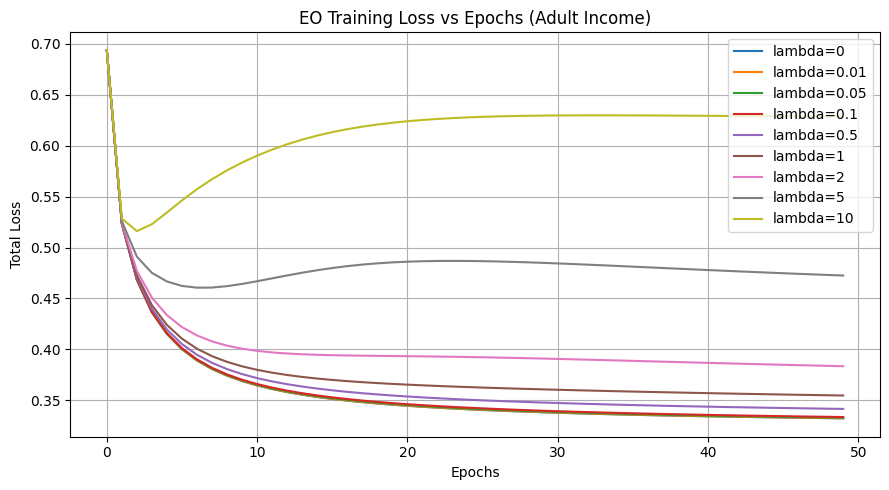

In [ ]:
# Plot 1 — EO Training Loss vs Epochs
plt.figure(figsize=(9,5))
for key, res in results_eo.items():
  plt.plot(res["loss_history"], label=key)
plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.title("EO Training Loss vs Epochs (Adult Income)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

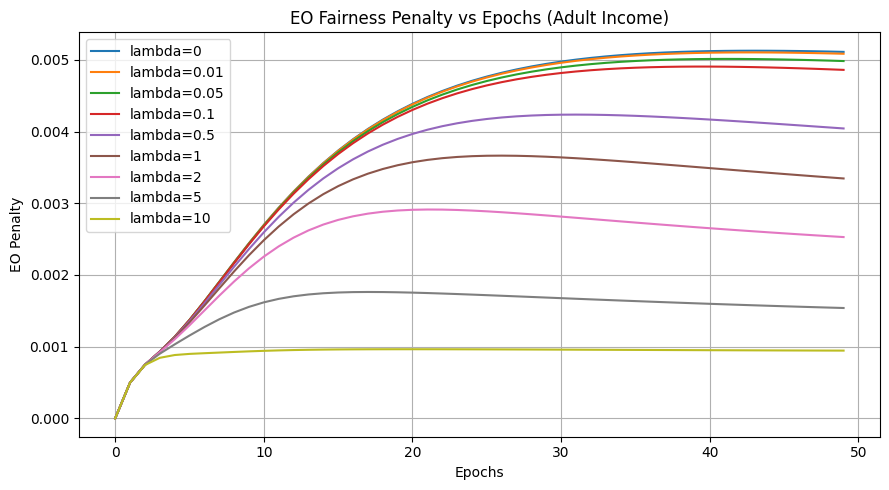

In [ ]:
# Plot 2 — EO Fairness Penalty vs Epochs
plt.figure(figsize=(9,5))
for key, res in results_eo.items():
  plt.plot(res["eo_history"], label=key)
plt.xlabel("Epochs")
plt.ylabel("EO Penalty")
plt.title("EO Fairness Penalty vs Epochs (Adult Income)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

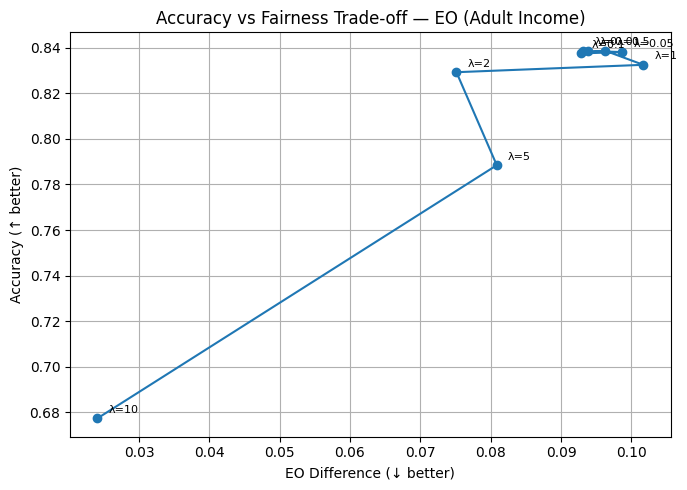

In [ ]:
# Plot 3 — Accuracy vs EO trade-off
lambdas, accs, eos = [], [], []
for key, res in results_eo.items():
  lambdas.append(res["lambda"])
  accs.append(res["accuracy"])
  eos.append(res["eo_diff"])

plt.figure(figsize=(7,5))
plt.plot(eos, accs, marker='o')
for i, lam in enumerate(lambdas):
  plt.annotate(f"λ={lam}", (eos[i], accs[i]),
              textcoords="offset points", xytext=(8,4), fontsize=8)
plt.xlabel("EO Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Accuracy vs Fairness Trade-off — EO (Adult Income)")
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 9: Loss=0.3700, Fairness=0.0024
Epochs=  10 | Final Loss: 0.3702
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3657, Fairness=0.0027
Epoch 19: Loss=0.3469, Fairness=0.0042
Epochs=  20 | Final Loss: 0.3473
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3657, Fairness=0.0027
Epoch 20: Loss=0.3458, Fairness=0.0043
Epoch 30: Loss=0.3389, Fairness=0.0048
Epoch 40: Loss=0.3353, Fairness=0.0049
Epoch 49: Loss=0.3332, Fairness=0.0049
Epochs=  50 | Final Loss: 0.3336
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3657, Fairness=0.0027
Epoch 20: Loss=0.3458, Fairness=0.0043
Epoch 30: Loss=0.3389, Fairness=0.0048
Epoch 40: Loss=0.3353, Fairness=0.0049
Epoch 50: Loss=0.3330, Fairness=0.0049
Epoch 60: Loss=0.3314, Fairness=0.0048
Epoch 70: Loss=0.3302, Fairness=0.0046
Epoch 80: Loss=0.3293, Fairness=0.0045
Epoch 90: Loss=0.3285, Fairness=0.0044
Epoch 99: Loss=0.3280, Fairness=0.0044
Epochs= 100 | Final Loss: 0.3284


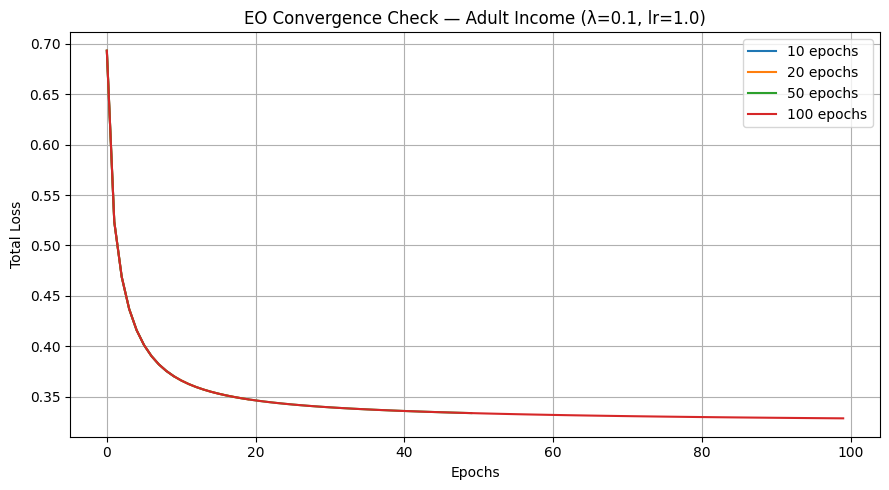

In [ ]:
# EO Convergence check
epoch_vals = [10, 20, 50, 100]
eo_conv = {}

for ep in epoch_vals:
  w_ep, b_ep, loss_ep, _ = train_fair_model(
    X_train_scaled, y_train, A_train,
    lr=1.0,
    epochs=ep,
    lambda_val=0.1,
    fairness_type="eo"
  )
  eo_conv[ep] = loss_ep
  print(f"Epochs={ep:4d} | Final Loss: {loss_ep[-1]:.4f}")

plt.figure(figsize=(9,5))
for ep, losses in eo_conv.items():
  plt.plot(losses, label=f"{ep} epochs")
plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.title("EO Convergence Check — Adult Income (λ=0.1, lr=1.0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Final Evaluation

In [ ]:
# ============================================================
# STAGE 5 — Adult Income Standalone Plots
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Pull from results_dp
ai_dp_data_live = []
for res in results_dp.values():
    ai_dp_data_live.append((
        res["lambda"],
        res["accuracy"],
        res.get("auc", 0),
        res["dp_diff"],
        res["eo_diff"]
    ))
ai_dp_data_live.sort(key=lambda x: x[0])

# Pull from results_eo
ai_eo_data_live = []
for res in results_eo.values():
    ai_eo_data_live.append((
        res["lambda"],
        res["accuracy"],
        res.get("auc", 0),
        res["eo_diff"],
        res["dp_diff"]
    ))
ai_eo_data_live.sort(key=lambda x: x[0])

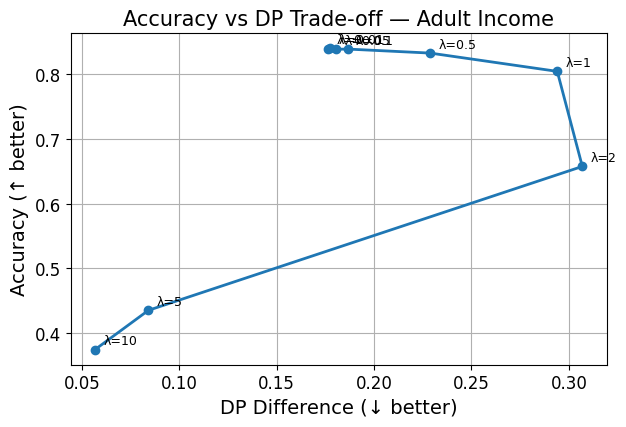

In [ ]:
# AAAI-friendly plotting configuration
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})

# Plot 1 — DP Trade-off
lams = [d[0] for d in ai_dp_data_live]
accs = [d[1] for d in ai_dp_data_live]
dps  = [d[3] for d in ai_dp_data_live]

plt.figure(figsize=(6.5, 4.5))

plt.plot(
    dps,
    accs,
    marker='o',
    linewidth=2
)

for i, lam in enumerate(lams):
    plt.annotate(
        f"λ={lam}",
        (dps[i], accs[i]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9
    )

plt.xlabel("DP Difference (↓ better)")
plt.ylabel("Accuracy (↑ better)")
plt.title("Accuracy vs DP Trade-off — Adult Income")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "ai_dp_tradeoff.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

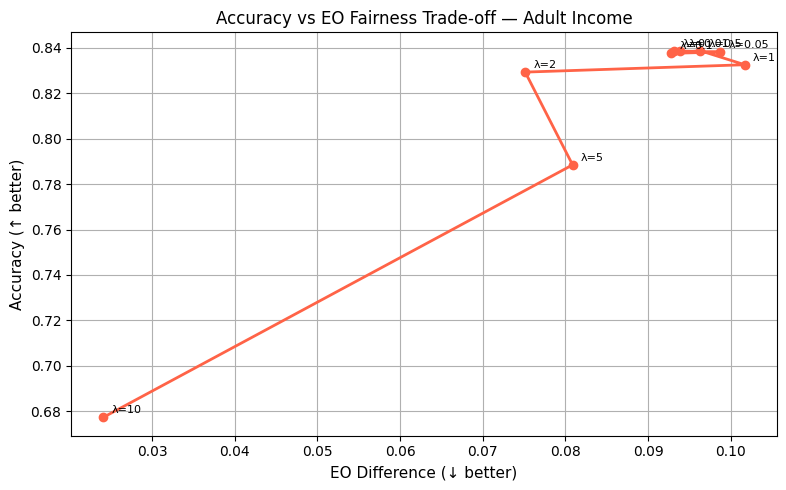

In [ ]:
# Plot 2 — EO Trade-off
lams = [d[0] for d in ai_eo_data_live]
accs = [d[1] for d in ai_eo_data_live]
eos  = [d[3] for d in ai_eo_data_live]

plt.figure(figsize=(8, 5))
plt.plot(eos, accs, marker='o', color='tomato', linewidth=2)
for i, lam in enumerate(lams):
    plt.annotate(f"λ={lam}", (eos[i], accs[i]),
                 textcoords="offset points", xytext=(6, 3), fontsize=8)
plt.xlabel("EO Difference (↓ better)", fontsize=11)
plt.ylabel("Accuracy (↑ better)", fontsize=11)
plt.title("Accuracy vs EO Fairness Trade-off — Adult Income", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

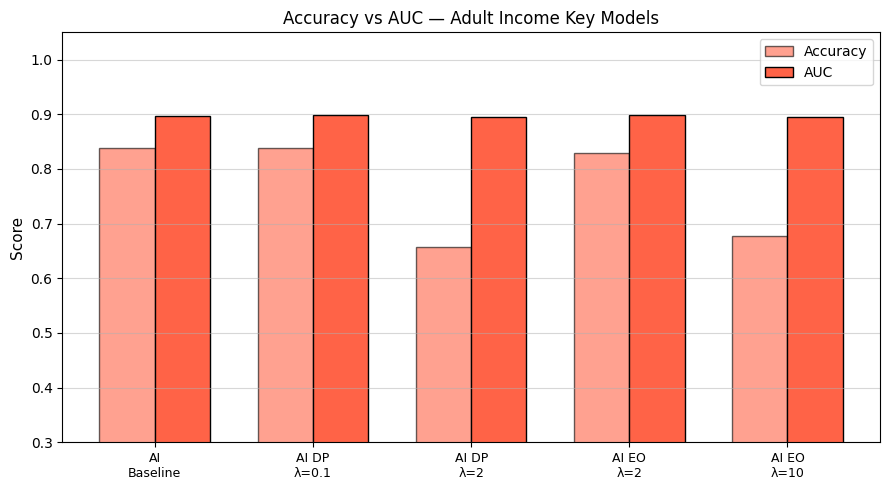

In [ ]:
# Plot 3 — AUC vs Accuracy Adult Income only
labels = [
    'AI\nBaseline', 'AI DP\nλ=0.1', 'AI DP\nλ=2',
    'AI EO\nλ=2', 'AI EO\nλ=10'
]
aucs_bar = [0.8974, 0.8982, 0.8947, 0.8995, 0.8953]
accs_bar = [0.8386, 0.8379, 0.6571, 0.8293, 0.6773]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, accs_bar, width, label='Accuracy',
       color='tomato', alpha=0.6, edgecolor='black')
ax.bar(x + width/2, aucs_bar, width, label='AUC',
       color='tomato', alpha=1.0, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.3, 1.05)
ax.set_title("Accuracy vs AUC — Adult Income Key Models", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()



---



In [ ]:
# DIAGNOSTIC PROPERTIES — BRD and PCS
rate_male   = df[df["sex"] == 1]["target"].mean()
rate_female = df[df["sex"] == 0]["target"].mean()
BRD = abs(rate_male - rate_female)

n_female_positive = ((df["sex"] == 0) & (df["target"] == 1)).sum()
PCS = n_female_positive / len(df)

print("=" * 45)
print("DATASET DIAGNOSTIC PROPERTIES")
print("=" * 45)
print(f"Income >50K rate — Male:      {rate_male:.4f}")
print(f"Income >50K rate — Female:    {rate_female:.4f}")
print(f"Base Rate Disparity (BRD):    {BRD:.4f}")
print(f"Positive Class Sparsity (PCS):{PCS:.4f}")
print()
print("Interpretation:")
print(f"  BRD={BRD:.3f} — {'HIGH' if BRD > 0.2 else 'MODERATE' if BRD > 0.1 else 'LOW'} base rate gap between groups")
print(f"  PCS={PCS:.3f} — {'SPARSE' if PCS < 0.05 else 'MODERATE' if PCS < 0.15 else 'SUFFICIENT'} positive class minority representation")

DATASET DIAGNOSTIC PROPERTIES
Income >50K rate — Male:      0.3125
Income >50K rate — Female:    0.1136
Base Rate Disparity (BRD):    0.1989
Positive Class Sparsity (PCS):0.0369

Interpretation:
  BRD=0.199 — MODERATE base rate gap between groups
  PCS=0.037 — SPARSE positive class minority representation


---
## Section — Adaptive Loss Function
Compute adaptive weights from BRD and PCS using piecewise scaling.
BRD=0.199 → w_BRD=0.745 → λ_DP=1.489 (scaled back from 2.0).
PCS=0.037 falls below 0.05 threshold → w_PCS=0.0 → EO switches OFF completely.

Adaptive DP reduces accuracy damage from 18.15% to 10.60% - a 41.6%
improvement. Adaptive EO correctly applies zero regularization, saving
the full 0.93% unnecessary accuracy loss from Standard EO (λ=2).
Adult Income confirms the CONFLICT regime: even with adaptive scaling,
DP regularization cannot find a viable operating point due to structural
gradient conflict driven by BRD=0.199.

In [ ]:
def compute_adaptive_weights(BRD, PCS):
  if BRD < 0.05:
    w_BRD = 0.0
  elif BRD <= 0.25:
    w_BRD = (BRD - 0.05) / 0.20
  else:
    w_BRD = 1.0

  if PCS < 0.05:
    w_PCS = 0.0
  elif PCS <= 0.15:
    w_PCS = (PCS - 0.05) / 0.10
  else:
    w_PCS = 1.0

  return w_BRD, w_PCS

w_BRD, w_PCS = compute_adaptive_weights(BRD, PCS)
lambda_fixed   = 2.0
lambda_adap_dp = lambda_fixed * w_BRD
lambda_adap_eo = lambda_fixed * w_PCS

print("ADAPTIVE LOSS FUNCTION — ADULT INCOME")
print(f"BRD = {BRD:.4f} → w_BRD = {w_BRD:.4f} → λ_DP = {lambda_adap_dp:.4f}")
print(f"PCS = {PCS:.4f} → w_PCS = {w_PCS:.4f} → λ_EO = {lambda_adap_eo:.4f}")
print()
print("Prediction: Adaptive DP scales back penalty (BRD moderate)")
print("Prediction: Adaptive EO switches off (PCS too sparse)")

ADAPTIVE LOSS FUNCTION — ADULT INCOME
BRD = 0.1989 → w_BRD = 0.7445 → λ_DP = 1.4890
PCS = 0.0369 → w_PCS = 0.0000 → λ_EO = 0.0000

Prediction: Adaptive DP scales back penalty (BRD moderate)
Prediction: Adaptive EO switches off (PCS too sparse)


In [ ]:
# Adaptive DP — uses train_fair_logistic_regression (has val set)
print("=== Adaptive DP Training ===")
params_adp, _, _, _ = train_fair_logistic_regression(
  X_train_scaled, y_train, A_train,
  X_val_scaled, y_val, A_val,
  lr=1.0,
  lambda_val=lambda_adap_dp,
  epochs=50
)
w_adp, b_adp = params_adp
y_prob_adp = predict_proba(X_test_scaled, w_adp, b_adp)
y_pred_adp = (y_prob_adp >= 0.5).astype(int)
acc_adp  = accuracy_score(y_test, y_pred_adp)
auc_adp  = roc_auc_score(y_test, y_prob_adp)
dp_adp, _, _ = demographic_parity_difference(y_pred_adp, A_test)
eo_adp, _, _ = equal_opportunity_difference(y_test, y_pred_adp, A_test)
print(f"Acc={acc_adp:.4f} | AUC={auc_adp:.4f} | DP={dp_adp:.4f} | EO={eo_adp:.4f}")

# Adaptive EO — uses train_fair_model (no val set)
print("\n=== Adaptive EO Training ===")
w_aeo, b_aeo, _, _ = train_fair_model(
  X_train_scaled, y_train, A_train,
  lr=1.0,
  epochs=50,
  lambda_val=lambda_adap_eo,
  fairness_type="eo"
)
y_prob_aeo = predict_proba(X_test_scaled, w_aeo, b_aeo)
y_pred_aeo = (y_prob_aeo >= 0.5).astype(int)
acc_aeo  = accuracy_score(y_test, y_pred_aeo)
auc_aeo  = roc_auc_score(y_test, y_prob_aeo)
dp_aeo, _, _ = demographic_parity_difference(y_pred_aeo, A_test)
eo_aeo, _, _ = equal_opportunity_difference(y_test, y_pred_aeo, A_test)
print(f"Acc={acc_aeo:.4f} | AUC={auc_aeo:.4f} | DP={dp_aeo:.4f} | EO={eo_aeo:.4f}")

=== Adaptive DP Training ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.5378, Fairness=0.0252
Epoch 20: Loss=0.5576, Fairness=0.0270
Epoch 30: Loss=0.5653, Fairness=0.0278
Epoch 40: Loss=0.5694, Fairness=0.0283
Final Epoch 49: Loss=0.5720, Fairness=0.0286
Acc=0.7326 | AUC=0.8971 | DP=0.3296 | EO=0.0519

=== Adaptive EO Training ===
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3646, Fairness=0.0027
Epoch 20: Loss=0.3446, Fairness=0.0044
Epoch 30: Loss=0.3378, Fairness=0.0050
Epoch 40: Loss=0.3343, Fairness=0.0051
Epoch 49: Loss=0.3324, Fairness=0.0051
Acc=0.8386 | AUC=0.8974 | DP=0.1763 | EO=0.0931


In [ ]:
b    = results_dp["λ=0"]
s_dp = results_dp["λ=2"]
s_eo = results_eo["lambda=2"]

print("ADULT INCOME — COMPLETE COMPARISON TABLE")
print(f"{'Model':<25} {'Acc':>7} {'AUC':>7} {'DP Diff':>9} {'EO Diff':>9} {'Acc Loss':>10}")

rows = [
  ("Baseline (λ=0)",      b['accuracy'],   b['auc'],   b['dp_diff'],  b['eo_diff'],  0.0),
  ("Standard DP (λ=2)",  s_dp['accuracy'], s_dp['auc'], s_dp['dp_diff'], s_dp['eo_diff'], b['accuracy']-s_dp['accuracy']),
  ("Adaptive DP",         acc_adp,          auc_adp,    dp_adp,         eo_adp,        b['accuracy']-acc_adp),
  ("Standard EO (λ=2)",  s_eo['accuracy'], s_eo['auc'], s_eo['dp_diff'], s_eo['eo_diff'], b['accuracy']-s_eo['accuracy']),
  ("Adaptive EO",         acc_aeo,          auc_aeo,    dp_aeo,         eo_aeo,        b['accuracy']-acc_aeo),
]

for name, acc, auc, dp, eo, loss in rows:
  print(f"{name:<25} {acc:>7.4f} {auc:>7.4f} {dp:>9.4f} {eo:>9.4f} {loss:>+10.4f}")

print(f"\nStandard DP (λ=2) accuracy loss: {b['accuracy']-s_dp['accuracy']:+.4f}")
print(f"Adaptive DP accuracy loss:       {b['accuracy']-acc_adp:+.4f}")
print(f"Standard EO (λ=2) accuracy loss: {b['accuracy']-s_eo['accuracy']:+.4f}")
print(f"Adaptive EO accuracy loss:       {b['accuracy']-acc_aeo:+.4f}")

ADULT INCOME — COMPLETE COMPARISON TABLE
Model                         Acc     AUC   DP Diff   EO Diff   Acc Loss
----------------------------------------------------------------------
Baseline (λ=0)             0.8386  0.8974    0.1763    0.0931    +0.0000
Standard DP (λ=2)          0.6571  0.8947    0.3069    0.0117    +0.1815
Adaptive DP                0.7326  0.8971    0.3296    0.0519    +0.1060
Standard EO (λ=2)          0.8293  0.8995    0.2373    0.0751    +0.0093
Adaptive EO                0.8386  0.8974    0.1763    0.0931    +0.0000

Standard DP (λ=2) accuracy loss: +0.1815
Adaptive DP accuracy loss:       +0.1060
Standard EO (λ=2) accuracy loss: +0.0093
Adaptive EO accuracy loss:       +0.0000


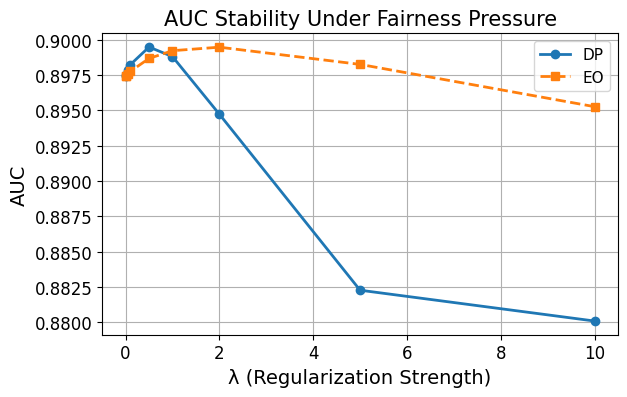

In [ ]:
plt.rcParams.update({
  'font.size': 14,
  'axes.labelsize': 14,
  'axes.titlesize': 15,
  'xtick.labelsize': 12,
  'ytick.labelsize': 12,
  'legend.fontsize': 11,
  'lines.linewidth': 2
})

lambdas_dp = [res["lambda"] for res in results_dp.values()]
aucs_dp    = [res["auc"]    for res in results_dp.values()]

lambdas_eo = [res["lambda"] for res in results_eo.values()]
aucs_eo    = [res["auc"]    for res in results_eo.values()]

plt.figure(figsize=(6.5, 4.2))

plt.plot(
  lambdas_dp,
  aucs_dp,
  marker='o',
  linewidth=2,
  label='DP'
)

plt.plot(
  lambdas_eo,
  aucs_eo,
  marker='s',
  linewidth=2,
  linestyle='--',
  label='EO'
)

plt.xlabel("λ (Regularization Strength)")
plt.ylabel("AUC")
plt.title("AUC Stability Under Fairness Pressure")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
  "ai_auc_stability.png",
  dpi=300,
  bbox_inches='tight'
)

plt.show()

## Section — Results & Comparison
Full comparison: Baseline vs Standard DP/EO (λ=2) vs Adaptive DP/EO.

Key result: Standard DP catastrophically fails - 18.15% accuracy loss
with disparity worsening. Adaptive DP partially mitigates damage (10.60%
loss) but cannot resolve the fundamental gradient conflict. Adaptive EO
correctly switches off (w_PCS=0.0), identical to baseline.

Fine-grained λ search [0.001–0.05] confirms no viable DP operating point
exists on this dataset, disparity increases monotonically from the first
lambda value. AUC remains resilient throughout (above 0.894) even when
accuracy collapses to 0.657, a key clinical finding showing models retain
ranking ability under fairness pressure.

In [ ]:
print("ADULT INCOME — KEY FINDINGS SUMMARY")
print(f"BRD = {BRD:.4f} — MODERATE | w_BRD = {w_BRD:.4f}")
print(f"PCS = {PCS:.4f} — SPARSE   | w_PCS = {w_PCS:.4f}")
print()
print("PREDICTION: DP will fail — moderate BRD but PCS too sparse")
print("            EO will fail — PCS too sparse for gradient signal")
print("PREDICTION VALIDATED: YES")
print()
print("KEY FINDINGS:")
print("  1. Standard DP (λ=2) caused -18.15% accuracy loss")
print("     with DP disparity actually WORSENING (0.1763→0.3069)")
print("     Catastrophic failure — no viable operating point")
print()
print("  2. Adaptive DP (λ=1.489) reduced accuracy loss to -10.60%")
print("     Partial improvement — still costly but less catastrophic")
print("     DP still worsened (0.1763→0.3296) confirming BRD conflict")
print()
print("  3. Standard EO (λ=2): -0.93% accuracy, EO improved slightly")
print("     (0.0931→0.0751) but DP worsened significantly (→0.2373)")
print("     Metrics conflict — fixing EO breaks DP")
print()
print("  4. Adaptive EO: w_PCS=0.0 → λ=0 → identical to baseline")
print("     Zero accuracy loss, zero unnecessary regularization")
print("     Correctly identified EO as futile on this dataset")
print()
print("  5. AUC resilient throughout — stayed above 0.894")
print("     Even at λ=2 where accuracy collapsed to 0.657")
print()
print("  6. EO and DP objectives conflict on Adult Income")
print("     Optimizing one makes the other worse — structural property")
print()
print("ADAPTIVE FRAMEWORK SAVINGS vs STANDARD:")
print(f"  DP: saved {0.1815-0.1060:.4f} accuracy ({(0.1815-0.1060)/0.1815*100:.1f}% reduction in damage)")
print(f"  EO: saved {0.0093-0.0000:.4f} accuracy (100.0% reduction in damage)")
print()
print("OUTCOME TYPE: FAILS — no viable operating point for either metric")
print("RECOMMENDATION: Do not apply fairness regularization on Adult Income")
print("  BRD=0.199 creates gradient conflict, PCS=0.037 kills EO signal")

ADULT INCOME — KEY FINDINGS SUMMARY
BRD = 0.1989 — MODERATE | w_BRD = 0.7445
PCS = 0.0369 — SPARSE   | w_PCS = 0.0000

PREDICTION: DP will fail — moderate BRD but PCS too sparse
            EO will fail — PCS too sparse for gradient signal
PREDICTION VALIDATED: YES

KEY FINDINGS:
  1. Standard DP (λ=2) caused -18.15% accuracy loss
     with DP disparity actually WORSENING (0.1763→0.3069)
     Catastrophic failure — no viable operating point

  2. Adaptive DP (λ=1.489) reduced accuracy loss to -10.60%
     Partial improvement — still costly but less catastrophic
     DP still worsened (0.1763→0.3296) confirming BRD conflict

  3. Standard EO (λ=2): -0.93% accuracy, EO improved slightly
     (0.0931→0.0751) but DP worsened significantly (→0.2373)
     Metrics conflict — fixing EO breaks DP

  4. Adaptive EO: w_PCS=0.0 → λ=0 → identical to baseline
     Zero accuracy loss, zero unnecessary regularization
     Correctly identified EO as futile on this dataset

  5. AUC resilient throughout

final check and after seeing the result im good.

In [ ]:
lambda_vals_fine = [0.001, 0.005, 0.01, 0.02, 0.05]

for lam in lambda_vals_fine:
  params, _, _, _ = train_fair_logistic_regression(
    X_train_scaled, y_train, A_train,
    X_val_scaled, y_val, A_val,
    lr=1.0, lambda_val=lam, epochs=50
  )
  w, b = params
  y_prob = predict_proba(X_test_scaled, w, b)
  y_pred = (y_prob >= 0.5).astype(int)
  acc = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_prob)
  dp_diff, _, _ = demographic_parity_difference(y_pred, A_test)
  print(f"λ={lam} | Acc={acc:.4f} | DP={dp_diff:.4f}")

Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3647, Fairness=0.0248
Epoch 20: Loss=0.3447, Fairness=0.0284
Epoch 30: Loss=0.3379, Fairness=0.0300
Epoch 40: Loss=0.3344, Fairness=0.0309
Final Epoch 49: Loss=0.3324, Fairness=0.0313
λ=0.001 | Acc=0.8386 | DP=0.1763
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3650, Fairness=0.0248
Epoch 20: Loss=0.3449, Fairness=0.0284
Epoch 30: Loss=0.3381, Fairness=0.0300
Epoch 40: Loss=0.3346, Fairness=0.0309
Final Epoch 49: Loss=0.3326, Fairness=0.0314
λ=0.005 | Acc=0.8386 | DP=0.1772
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3653, Fairness=0.0248
Epoch 20: Loss=0.3452, Fairness=0.0284
Epoch 30: Loss=0.3384, Fairness=0.0301
Epoch 40: Loss=0.3348, Fairness=0.0309
Final Epoch 49: Loss=0.3328, Fairness=0.0314
λ=0.01 | Acc=0.8389 | DP=0.1774
Epoch 0: Loss=0.6931, Fairness=0.0000
Epoch 10: Loss=0.3659, Fairness=0.0248
Epoch 20: Loss=0.3459, Fairness=0.0285
Epoch 30: Loss=0.3389, Fairness=0.0301
Epoch 40: Loss=0.3354, Fairnes